# DSN AI BOOTCAMP 2026 QUALIFIER PROJECT

## Problem statement
- DSN Mart operates a chain of stores across Nigeria, from small corner shops to flagship hypermarkets, spread across major urban centres, state capitals, and smaller towns. Like any growing retail business, DSN Mart wants to understand what drives sales at the product level across its different store formats and locations, so it can plan stock, pricing, and store investment more intelligently. Build a machine learning model that predicts total sales for a given product at a given store, based on what's known about the product and the outlet it's sold in. 

# 1. Reading train and test datasets, and also trying to get familiar with my dataset

In [2]:
## Import all important libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline

In [3]:
# reading the train data using pandas module.
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [4]:
train_df.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [5]:
test_df

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket
...,...,...,...,...,...,...,...,...,...,...,...,...
1700,row_08483,PRD-58L9K5,17.919,Low Fat,0.0607,Starchy Foods,168.62,STORE-89Z,33,Medium,Tier_1,Standard Supermarket
1701,row_08489,PRD-0B58ST,16.748,Regular,0.0136,canned,97.26,STORE-JOR,34,NaN,Tier_3,Corner Shop
1702,row_08491,PRD-RH8H90,9.876,Low Fat,0.0239,health and hygiene,183.35,STORE-HL7,23,Medium,Tier_3,Superstore
1703,row_08504,PRD-J51IFI,NaN,Low Fat,0.0221,Breads,166.09,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket


In [6]:
train_df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [7]:
test_df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years
count,1399.000000,1705.000000,1705.000000,1705.000000
mean,12.865960,0.068491,143.069490,34.127859
std,4.647713,0.051721,61.888692,8.322650
min,4.693000,0.000000,31.980000,23.000000
25%,8.753000,0.030200,96.560000,28.000000
50%,12.617000,0.056400,144.630000,33.000000
75%,16.915500,0.098400,185.210000,45.000000
max,21.980000,0.302000,270.870000,47.000000


In [8]:
train_df.shape

(6818, 13)

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [10]:
train_df.isna().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [11]:
# Dropping the most useless columns in the dataset.
train_df.drop('id', axis=1, inplace=True)

In [12]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06


In [13]:
train_df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [14]:
train_df['product_weight_kg'].isna().sum()

np.int64(1225)

In [15]:
train_df['product_weight_kg'].unique()


array([14.252,  7.698, 14.264, ..., 15.77 , 17.665, 16.703], shape=(4676,))

In [16]:
train_df['product_weight_kg'].mode()

0    7.692
1    8.097
Name: product_weight_kg, dtype: float64

In [17]:
train_df['product_weight_kg'].mean()

np.float64(12.850875916323977)

In [18]:
train_df['product_weight_kg'].value_counts()

product_weight_kg
8.097     5
7.692     5
17.659    4
9.503     4
11.844    4
         ..
7.374     1
18.238    1
11.586    1
14.179    1
16.703    1
Name: count, Length: 4675, dtype: int64

In [19]:
train_df['product_code'].unique()

array(['PRD-PRFP9S', 'PRD-PXXK71', 'PRD-V5MOIJ', ..., 'PRD-AF3WE8',
       'PRD-06GUU9', 'PRD-7Q5FPH'], shape=(1555,), dtype=object)

In [20]:
train_df['product_code'].mode()[0]

'PRD-YZB4K8'

In [21]:
train_df['store_code'].unique()

array(['STORE-AGY', 'STORE-YLW', 'STORE-89Z', 'STORE-7WS', 'STORE-9RG',
       'STORE-HL7', 'STORE-JOR', 'STORE-T5G', 'STORE-OYG', 'STORE-DKU'],
      dtype=object)

In [22]:
train_df['store_code'].value_counts()

store_code
STORE-YLW    754
STORE-9RG    752
STORE-AGY    748
STORE-7WS    748
STORE-OYG    744
STORE-HL7    742
STORE-DKU    736
STORE-89Z    728
STORE-JOR    439
STORE-T5G    427
Name: count, dtype: int64

In [23]:
train_df[train_df['store_code']=='STORE-YLW']

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
1,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
13,PRD-PGW90J,13.812,Low Fat,0.0431,Dairy,52.83,STORE-YLW,35,Small,Tier_1,Standard Supermarket,585.91
23,PRD-2YAZQT,15.428,Regular,0.0819,Frozen Foods,48.98,STORE-YLW,35,Small,Tier_1,Standard Supermarket,753.42
24,PRD-Q8LYYX,11.265,Regular,0.0735,Frozen Foods,171.96,STORE-YLW,35,Small,Tier_1,Standard Supermarket,2442.31
29,PRD-2SLHIM,20.799,Low Fat,0.0099,Meat,187.29,STORE-YLW,35,Small,Tier_1,Standard Supermarket,536.28
...,...,...,...,...,...,...,...,...,...,...,...,...
6797,PRD-R04H5W,19.232,Low Fat,0.0000,household,190.57,STORE-YLW,35,Small,Tier_1,Standard Supermarket,555.26
6806,PRD-LJKPHC,18.780,Regular,0.0958,Fruits and Vegetables,82.59,STORE-YLW,35,Small,Tier_1,Standard Supermarket,1124.02
6809,PRD-I67HN3,20.547,Low Fat,0.0102,Household,233.74,STORE-YLW,35,Small,Tier_1,Standard Supermarket,3212.38
6812,PRD-JNODL5,18.365,Low Fat,0.0154,Health and Hygiene,161.04,STORE-YLW,35,Small,Tier_1,Standard Supermarket,1588.25


In [24]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06


# 2. Missing Values Handling/Data Cleaning

## Resolving missing values in product_weight_kg
- The same product_code appears in multiple rows meaning a product is sold at different stores, so if the weight is known for that product anywhere else, we can find the actual value instead of guessing one for it.

In [25]:
# I replaced all inconsistent headers in the product_category column.
train_df['product_category'] = train_df['product_category'].str.strip().str.lower()

In [26]:
## filling missing values in numerical variable "Product_weight_kg" with its median
train_df['product_weight_kg'] = train_df.groupby('product_code')['product_weight_kg'].transform(lambda x: x.fillna(x.median()))

In [27]:
train_df['product_weight_kg'] = train_df.groupby('product_category')['product_weight_kg'].transform(lambda x: x.fillna(x.median()))

In [28]:
train_df['product_weight_kg'].isna().sum()

np.int64(0)

In [29]:
train_df.isnull().sum()

product_code              0
product_weight_kg         0
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [30]:
train_df[train_df['store_code']=='STORE-JOR']

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
9,PRD-DH2TA3,8.755,Low Fat,0.0258,household,104.60,STORE-JOR,34,NaN,Tier_3,Corner Shop,213.93
30,PRD-NAMSQE,12.376,Regular,0.2992,baking goods,79.91,STORE-JOR,34,NaN,Tier_3,Corner Shop,150.54
44,PRD-4CK9XH,12.451,Low Fat,0.1737,household,169.29,STORE-JOR,34,NaN,Tier_3,Corner Shop,166.62
78,PRD-1N8MTZ,19.413,Low Fat,0.0421,dairy,44.58,STORE-JOR,34,NaN,Tier_3,Corner Shop,47.21
96,PRD-2EZP7V,12.766,Low Fat,0.0329,health and hygiene,101.70,STORE-JOR,34,NaN,Tier_3,Corner Shop,206.34
...,...,...,...,...,...,...,...,...,...,...,...,...
6739,PRD-UP0URE,12.199,Regular,0.1167,dairy,47.14,STORE-JOR,34,NaN,Tier_3,Corner Shop,49.73
6744,PRD-VCZHN7,11.202,Low Fat,0.2755,snack foods,126.52,STORE-JOR,34,NaN,Tier_3,Corner Shop,377.64
6745,PRD-5WVO01,5.219,Low Fat,0.0532,health and hygiene,33.64,STORE-JOR,34,NaN,Tier_3,Corner Shop,73.10
6771,PRD-V5MOIJ,14.578,Regular,0.0669,canned,41.55,STORE-JOR,34,NaN,Tier_3,Corner Shop,41.63


## Resolving missing values in store_size.

- All missing rows come from 3 specific stores that never report store_size at all (whole store, not scattered rows) - so we can't recover it from other rows of the same store like we did for weight. Instead, store_format + store_location_tier are strongly related to store_size, so we use the most common (mode) store_size within those groups, with fallbacks in case a group combination was never observed.

In [31]:
train_df['store_size_was_missing'] = train_df['store_size'].isna().astype(int)

In [32]:
known = train_df.dropna(subset=['store_size'])

In [33]:
combo_mode = (known.groupby(['store_format', 'store_location_tier'])['store_size'].agg(lambda x: x.mode()[0]))

In [34]:
format_mode = known.groupby('store_format')['store_size'].agg(lambda x: x.mode()[0])

In [35]:
global_mode = known['store_size'].mode()[0]

In [36]:
def fill_store_size(row):
    if pd.notna(row['store_size']):
        return row['store_size']
        
    key = (row['store_format'], row['store_location_tier'])
    
    if key in combo_mode.index:
        return combo_mode[key]
    if row['store_format'] in format_mode.index:
        return format_mode[row['store_format']]
    return global_mode

In [37]:
train_df['store_size'] = train_df.apply(fill_store_size, axis=1)

In [38]:
train_df.isnull().sum()

product_code              0
product_weight_kg         0
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size                0
store_location_tier       0
store_format              0
total_sales               0
store_size_was_missing    0
dtype: int64

In [39]:
train_df['store_size'].unique()

array(['Large', 'Small', 'Medium'], dtype=object)

In [40]:

train_df.duplicated

<bound method DataFrame.duplicated of      product_code  product_weight_kg fat_content  shelf_visibility  \
0      PRD-PRFP9S             14.252     Low Fat            0.0271   
1      PRD-PXXK71              7.698     Low Fat            0.0720   
2      PRD-V5MOIJ             14.264     Regular            0.0421   
3      PRD-UN5Z3J             12.665     Regular            0.0449   
4      PRD-6RDQYB             10.338     Regular            0.0120   
...           ...                ...         ...               ...   
6813   PRD-V56VKT              9.201     Regular            0.2851   
6814   PRD-S1AWP0             15.770     Low Fat            0.1193   
6815   PRD-NCP2VI             17.665     Low Fat            0.0182   
6816   PRD-K9LSG4             20.645     Low Fat            0.0567   
6817   PRD-ON4O79             16.703     Low Fat            0.0165   

           product_category  product_price store_code  store_age_years  \
0              frozen foods          81.37  STO

In [41]:
train_df


,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,store_size_was_missing
0,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,0
1,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,0
2,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,0
3,PRD-UN5Z3J,12.665,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,0
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50,1
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63,1
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55,1
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06,1


In [42]:
train_df[train_df['store_size']=='Small']

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,store_size_was_missing
1,PRD-PXXK71,7.6980,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,0
4,PRD-6RDQYB,10.3380,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,0
9,PRD-DH2TA3,8.7550,Low Fat,0.0258,household,104.60,STORE-JOR,34,Small,Tier_3,Corner Shop,213.93,1
10,PRD-ONGWUL,12.9695,Low Fat,0.0730,household,254.12,STORE-T5G,47,Small,Tier_1,Corner Shop,250.01,0
11,PRD-UX01UP,11.0070,Low Fat,0.0304,snack foods,234.38,STORE-OYG,25,Small,Tier_2,Standard Supermarket,4414.42,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.2010,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50,1
6814,PRD-S1AWP0,15.7700,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63,1
6815,PRD-NCP2VI,17.6650,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55,1
6816,PRD-K9LSG4,20.6450,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06,1


In [43]:
# Checking the relationship between location of a store and its size.
pd.crosstab(train_df['store_location_tier'], train_df['store_size'], dropna=False)

store_size,Large,Medium,Small
store_location_tier,,,
Tier_1,0,728,1181
Tier_2,0,0,2232
Tier_3,748,1490,439


In [44]:
train_df.drop('store_size_was_missing', axis=1, inplace=True)

In [45]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,12.665,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06


In [46]:
train_df['product_category']

0                frozen foods
1          health and hygiene
2                      canned
3                 soft drinks
4                        meat
                ...          
6813    fruits and vegetables
6814             frozen foods
6815       health and hygiene
6816              snack foods
6817                household
Name: product_category, Length: 6818, dtype: object

In [47]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,12.665,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06


In [48]:
train_df.isnull().sum()

product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

In [49]:
train_df.columns

Index(['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility',
       'product_category', 'product_price', 'store_code', 'store_age_years',
       'store_size', 'store_location_tier', 'store_format', 'total_sales'],
      dtype='object')

In [50]:
train_df.shape

(6818, 12)

In [51]:
train_df.columns

Index(['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility',
       'product_category', 'product_price', 'store_code', 'store_age_years',
       'store_size', 'store_location_tier', 'store_format', 'total_sales'],
      dtype='object')

In [52]:
train_df.dtypes

product_code            object
product_weight_kg      float64
fat_content             object
shelf_visibility       float64
product_category        object
product_price          float64
store_code              object
store_age_years          int64
store_size              object
store_location_tier     object
store_format            object
total_sales            float64
dtype: object

In [53]:
train_df['shelf_visibility'].astype(int)

0       0
1       0
2       0
3       0
4       0
       ..
6813    0
6814    0
6815    0
6816    0
6817    0
Name: shelf_visibility, Length: 6818, dtype: int64

In [54]:
train_df['total_sales'].astype(int)

0       1764
1        342
2        378
3       5595
4       2375
        ... 
6813     276
6814    1265
6815    6254
6816    1658
6817     987
Name: total_sales, Length: 6818, dtype: int64

In [55]:
train_df['product_price'].astype(int)

0        81
1        42
2        41
3       174
4       203
       ... 
6813    136
6814     74
6815    234
6816    118
6817     97
Name: product_price, Length: 6818, dtype: int64

In [56]:
train_df['product_weight_kg'].astype(int)

0       14
1        7
2       14
3       12
4       10
        ..
6813     9
6814    15
6815    17
6816    20
6817    16
Name: product_weight_kg, Length: 6818, dtype: int64

In [57]:
train_df

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,PRD-PXXK71,7.698,Low Fat,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,PRD-UN5Z3J,12.665,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,PRD-V56VKT,9.201,Regular,0.2851,fruits and vegetables,136.57,STORE-JOR,34,Small,Tier_3,Corner Shop,276.50
6814,PRD-S1AWP0,15.770,Low Fat,0.1193,frozen foods,74.03,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1265.63
6815,PRD-NCP2VI,17.665,Low Fat,0.0182,health and hygiene,234.87,STORE-DKU,30,Small,Tier_2,Standard Supermarket,6254.55
6816,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,Small,Tier_2,Standard Supermarket,1658.06


# 3. EDA
- We'll be checking the relationships between cateorical features and numerical features.
- We'll be checking the relationships between numerical features.
- We'll be checking the relationship numerical features has with itself likewise categorical features also has with itself.
- We'll be checking the skewness of the data, pinpointing outliers also. 

## - Starting with the numerical columns/features.

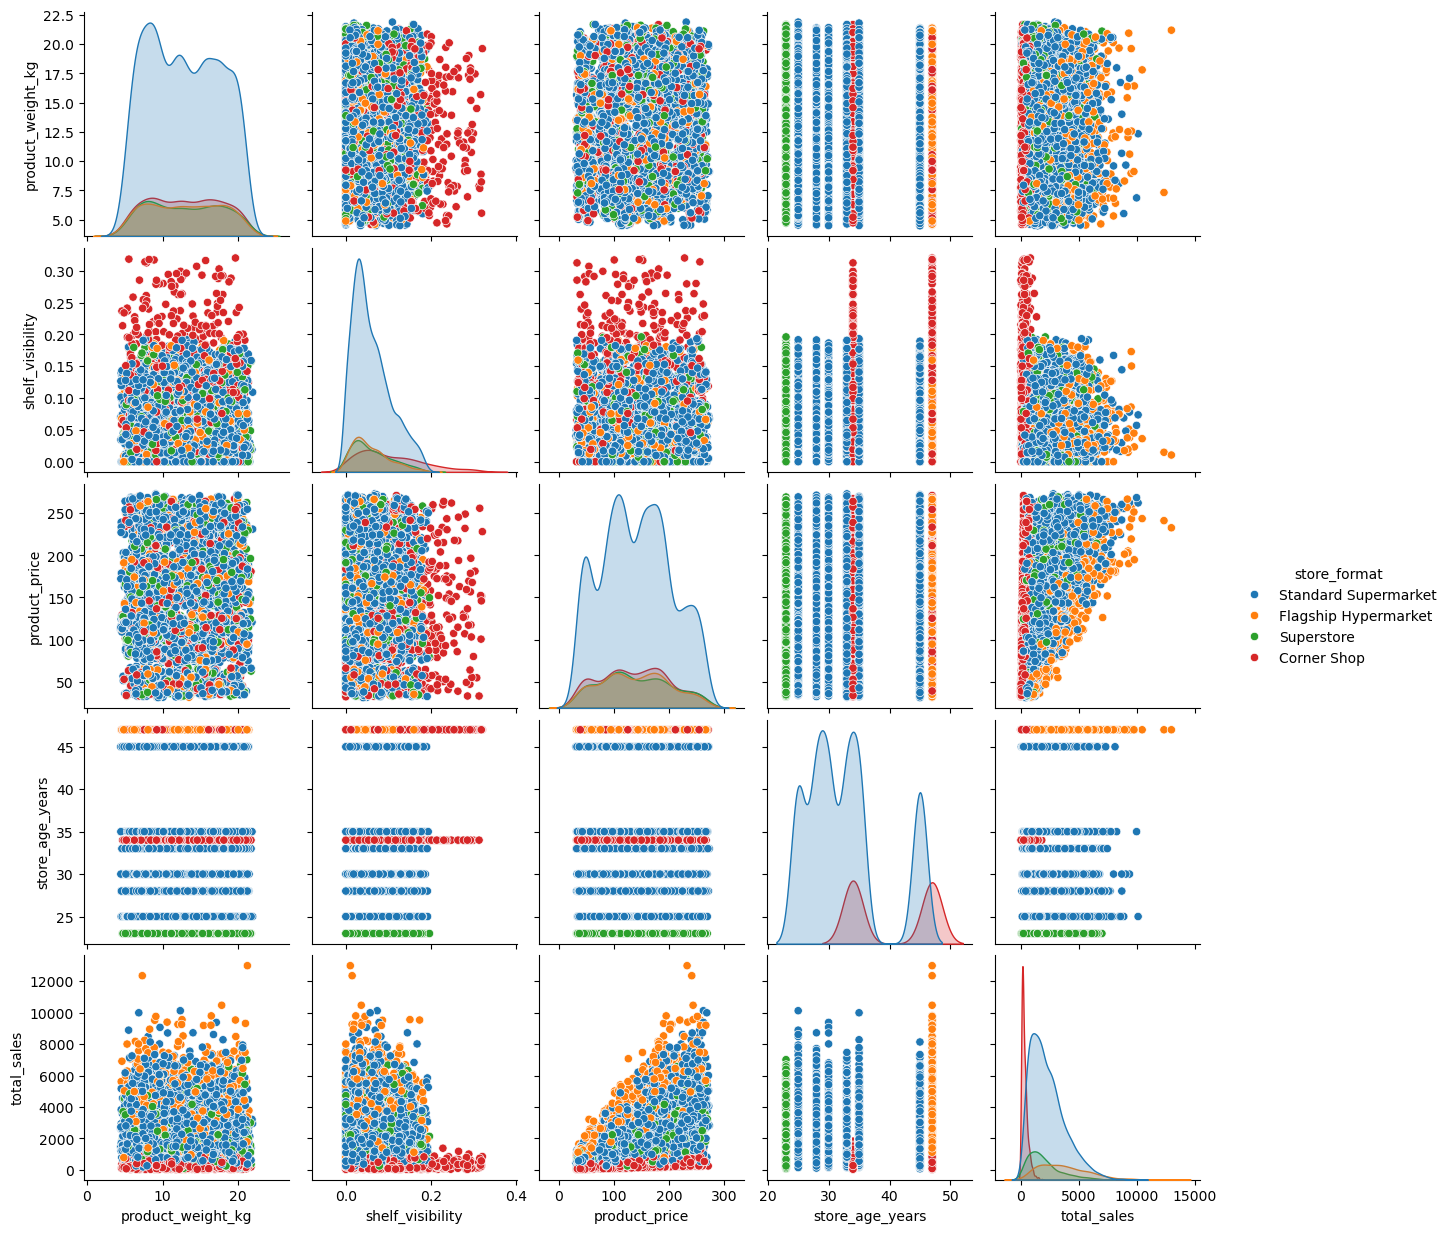

In [58]:
sns.pairplot(train_df, hue='store_format')

## - Checking for skewness in the numerical columns and afterwards i'll check for outliers.

In [59]:
num_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']

### - Looking at the Shape of the Numbers
- Let's check if each number column is balanced or lopsided.

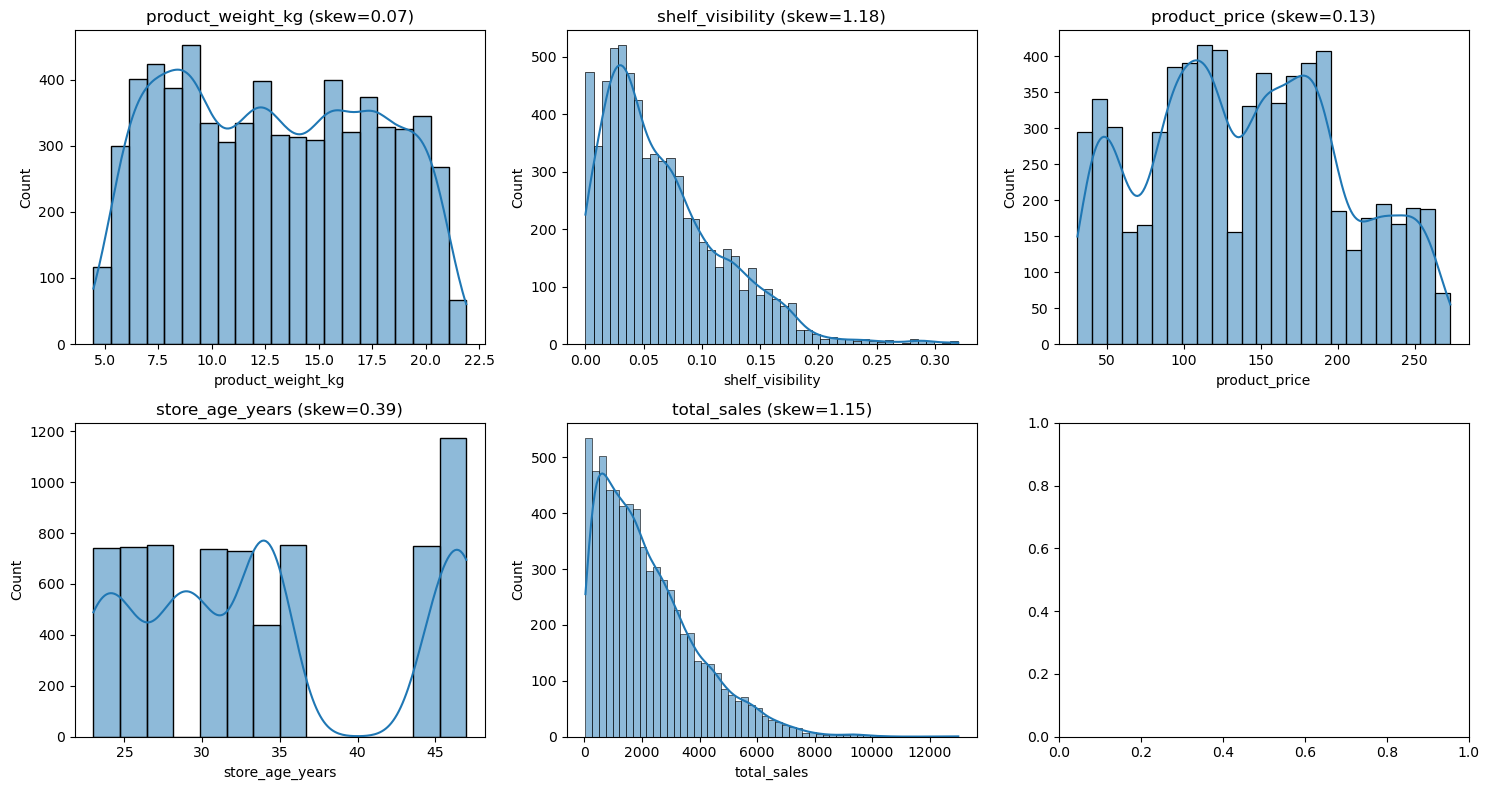

In [60]:
# distribution shape
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(train_df[col], kde=True, ax=ax)
    ax.set_title(f'{col} (skew={train_df[col].skew():.2f})')
plt.tight_layout()

- Looking at the plots above: `product_weight_kg`, `product_price`, and `store_age_years` all look pretty balanced — nothing weird going on. But `shelf_visibility` and `total_sales` are lopsided — most values are small, with a few really big ones stretching the tail out to the right and pulling the average up.

`shelf_visibility` and `total_sales` were the lopsided ones, so let's zoom in on those two and see if there are any extreme values sitting way outside the normal range.

In [ ]:
# Checking for Outliers in my train dataset
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=train_df['shelf_visibility'], ax=axes[0])
sns.boxplot(y=train_df['total_sales'], ax=axes[1])

- Yep — both columns have a whole lot of dots sitting above the box, meaning real outliers. I'm not deleting them though. In real store data, it's totally normal for a handful of products or stores to massively outsell everyone else, so these are probably genuine high performers, not mistakes in the data.

## - Now unto the Categorical columns.

Now let's see how the category-type columns are distributed — is each one fairly balanced, or do some values show up way more than others?

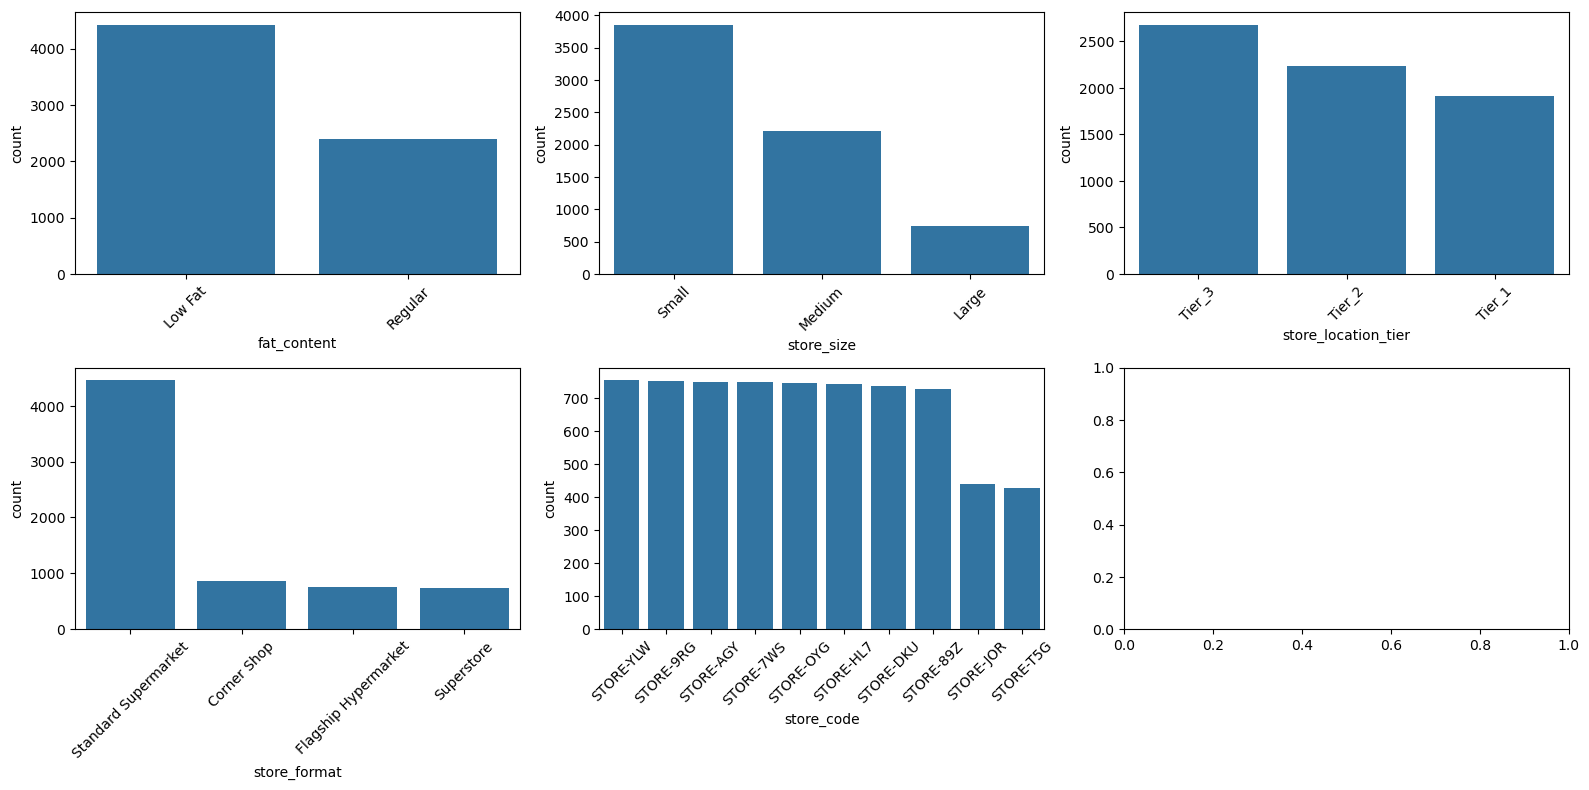

In [70]:
# I want to explore what the categorical columns look like on plots
cat_cols = ['fat_content', 'store_size', 'store_location_tier', 'store_format', 'store_code']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=train_df, x=col, ax=ax, order=train_df[col].value_counts().index)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

- `fat_content` is basically split down the middle between `Low Fat` and `Regular`.  Most of the 10 stores have a similar number of rows, except two (`STORE-JOR` and `STORE-T5G`) which have noticeably fewer. These are the same two stores that were missing `store_size` earlier.

<Axes: xlabel='count', ylabel='product_category'>

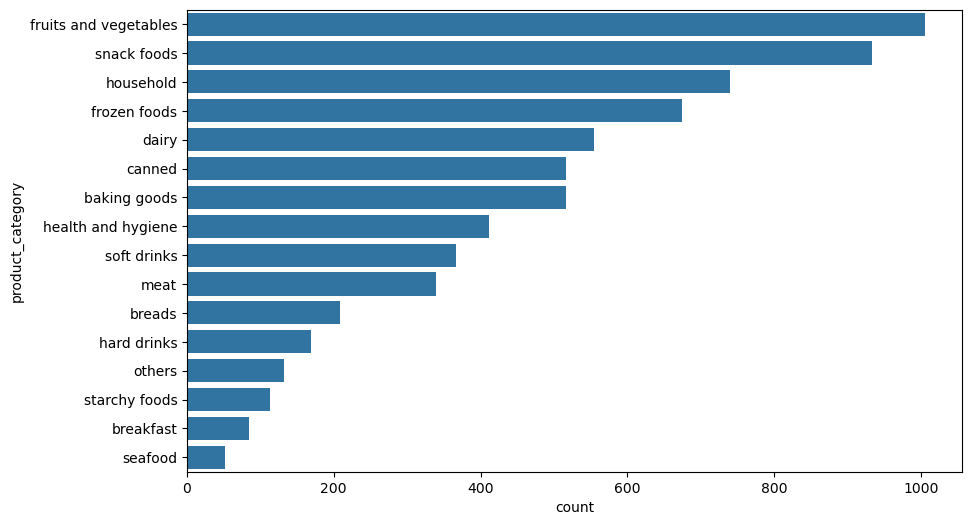

In [63]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, y='product_category', order=train_df['product_category'].value_counts().index)

- `product_category` isn't balanced at all though — `fruits and vegetables` and `snack foods` show up the most, while `seafood` and `breakfast` barely show up.

## - I've plotted so many plots, but one question remains unanswered. How does each feature relate to the total sales??
- The answer will be at the next cells.

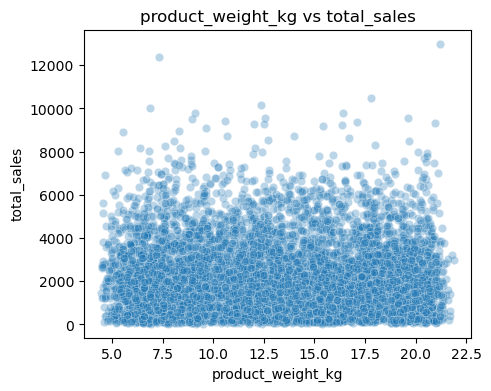

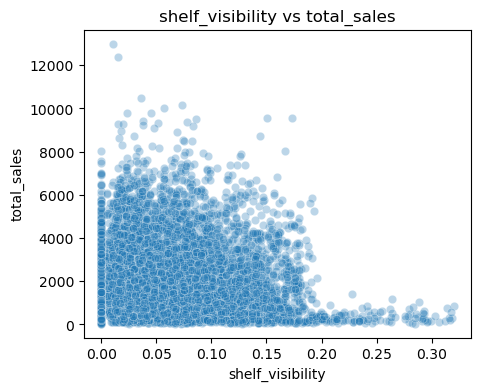

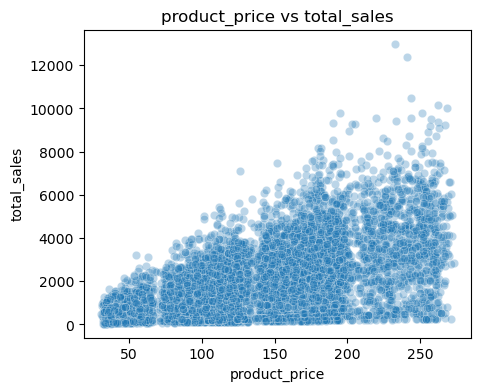

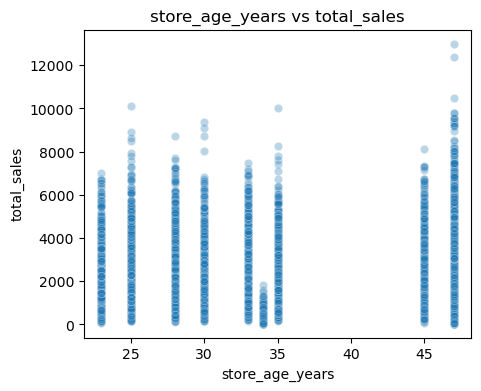

In [64]:
# Plots of numerical datas vs total_sales
for col in ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(data=train_df, x=col, y='total_sales', alpha=0.3)
    plt.title(f'{col} vs total_sales')

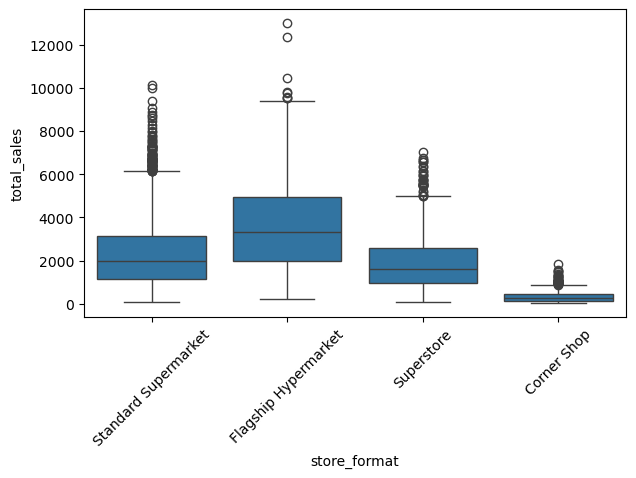

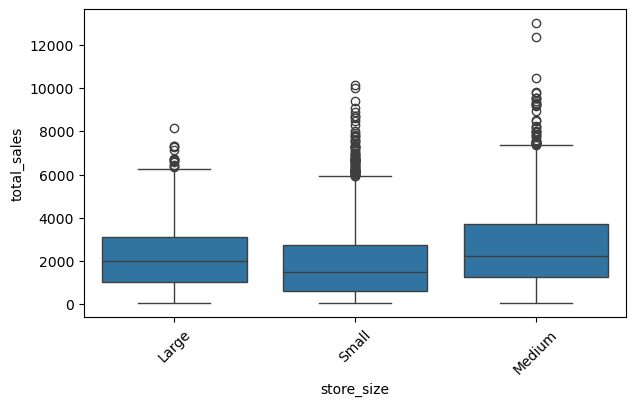

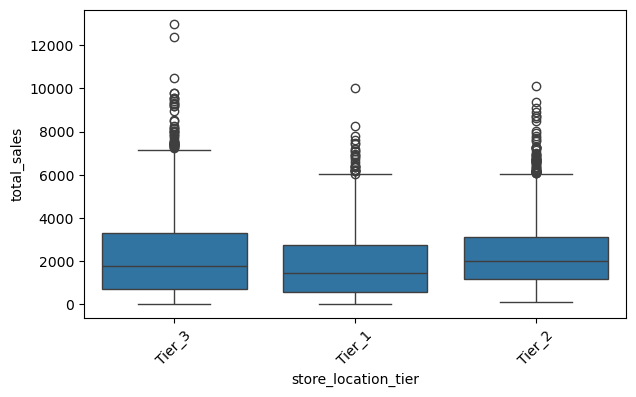

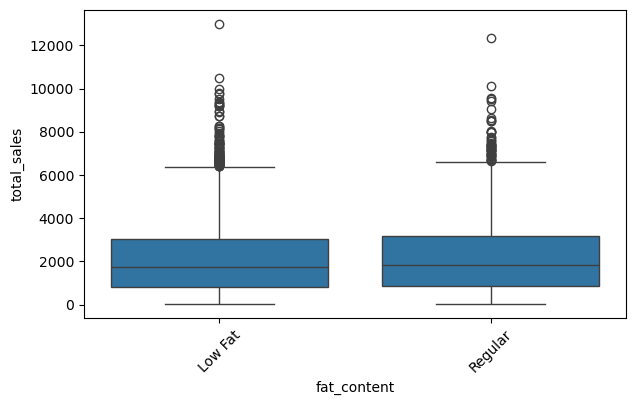

In [65]:
## Categorical features against the target feature.
for col in ['store_format', 'store_size', 'store_location_tier', 'fat_content']:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train_df, x=col, y='total_sales')
    plt.xticks(rotation=45)

- `product_price` stood out the most; higher price generally lines up with higher sales. `store_age_years` and `product_weight_kg` barely seem to matter on their own. `shelf_visibility` actually had a slight negative connection with sales, which is a little surprising, but I'm just noting it, not trying to explain it away.

- For the category columns: `store_format` made the biggest difference by far — `Flagship Hypermarket` stores sell way more on average than `Corner Shop` stores (more than 10x higher). `store_size` and `store_location_tier` also showed some difference, with `Medium` stores and `Tier_2` locations doing best. `fat_content` barely made any difference, so it's probably not a big deal for predicting sales.

<Axes: >

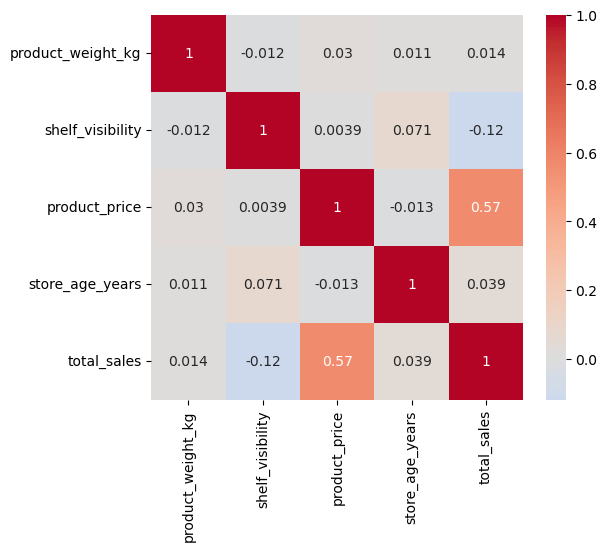

In [66]:
## Numerical columns against the correlation of the Numeric columns.
plt.figure(figsize=(6, 5))
sns.heatmap(train_df[num_cols].corr(), annot=True, cmap='coolwarm', center=0)

- They're not overlapping. all the numerical columns are pretty independent of each other. That's good news, it means each one brings its own unique information instead of repeating what another column already tells us.

## What I Learned From All This

- `product_price` and `store_format` seem to matter the most for predicting sales.
- Things like `product_weight_kg` and how old the store is don't seem to matter much on their own.
- `total_sales` and `shelf_visibility` are lopsided and have some big outlier values — something to keep in mind before building a model.
- Some categories (like product type and store) aren't evenly represented, so that's something to watch out for later.
- Next step: turn the text/category columns into numbers so a model can actually use them.
